In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
from scipy import linalg as la
import model as m

NOTE: $D$ apparently is not a 'controllable' variable. So including it in our state equation + cost functional is bad. We changed the model so if you specify `no_dead=True` in the constructor then it will not output $D$ which is fine because we can compute it by subtracting the sum of the other variables from the total initial population. - Jeremy + Henry.

In [ ]:
# Define Q and R in our LQR model
Q = np.array([[0, 0, 0],
             [0, 10, 0],
             [0, 0, 0]])

R = np.eye(2)

tf = 10 # total length of time full solution will be on (so tf = M * tn where M is however many times we linearize)

def solve_linearized(A, B, y0, tf):
    '''
    Solve for control and state given a linearized system on an interval of length tn
    x_dot = Ax + Bu
    y0 - initial conditions (or last value or previous solution to linearized system)
    tn - length of one time that system is linearized on

    returns a solution to linerized system for tn years (run solve_linearized multiple times and then
    concatenate the solutions together)

    Basically one iteration of iterated LQR (?)
    '''

    # solve continuous algebraic Riccati equation to get P
    P = la.solve_continuous_are(A, B, Q, R)

    print(P)

    # state equation Ax + 1/2 B R^-1 B^T lambda but lambda = -2Px by 
    def chytrid_evolve(t, y):
        return (A @ y - B @ B.T @ P @ y) # no R^-1 since thats just I

    #s olve the optimal state evolution, and plot the position & velocity
    sol = solve_ivp(chytrid_evolve, [0, tf], y0, dense_output=True)
    t = np.linspace(0, tf, 1001)
    # S, I, T1, D = sol.sol(t)
    S, I, T1 = sol.sol(t)

    # can prob just return the solution but just wanted to plot to test
    # plt.title("Optimal State for Linearized Chytrid")
    # plt.plot(t, S, label="Susceptible")
    # plt.plot(t, I, label="Infected")
    # plt.plot(t, T1, label="In Treatment 1")
    # plt.plot(t, D, label="Death")
    # plt.legend()

    u = - B.T @ P @ sol.sol(t)  # control

    return np.array([S[0], I[0], T1[0]]), u[:, 0]


# TODO get sympy to linearize A and B from our model which is imported above with namespace m

# (A and B below are DUMMY standins to test if above code would run)
A = np.array([[0, 3, 0, 0],
             [-2, 1, 6, 6],
             [0, 0, 2, 3],
             [0, 0, 0, 1]])

B = np.array([[1, 0],
             [1, 0],
             [1, 0],
             [1, 1]])

# initial guess 
# TODO: MIGHT NEED AN INITIAL GUESS FOR CONTROL 
y0 = np.array([475, 25, 0, 0])

# test
y0 = np.array([475, 25, 0])

# TODO determine how often we want to re-linearize our system 
# TODO figure out how to iterate
# solve_linearized(A, B, y0, 10)

In [3]:
tf = 0.5
t_steps = 100
t_space = np.linspace(0, tf, t_steps)
model = m.Model(seasonal=False, no_dead=True)


<class 'sympy.matrices.dense.MutableDenseMatrix'> Matrix([[-I*S*α + I*u2*η/(100*I + 5000) - S*ζ*(-2*T1/(365*u1) + 1) + T1*γ], [I*S*α - I*u2*η/(100*I + 5000) - I*β - I*ζ*(-2*T1/(365*u1) + 1)], [-T1*γ + ζ*(I + S)*(-2*T1/(365*u1) + 1)]])


[[ 768.94344142  768.94344142  768.77028468]
 [ 768.94344142 3405.32095485  748.98094339]
 [ 768.77028468  748.98094339  768.74852813]]
[[151.03523051 151.03523051 151.00000734]
 [151.03523051 668.87030656 146.97450145]
 [151.00000734 146.97450145 150.99910708]]
[[ 596.37457807  596.37457807  596.23705121]
 [ 596.37457807 2641.08741716  580.51969644]
 [ 596.23705121  580.51969644  596.22332703]]
[[220.86200374 220.86200374 220.80969561]
 [220.86200374 978.10315944 214.83162312]
 [220.80969561 214.83162312 220.8077102 ]]
[[ 521.65951588  521.65951588  521.53807404]
 [ 521.65951588 2310.20642748  507.65900604]
 [ 521.53807404  507.65900604  521.52737245]]
[[ 263.92302825  263.92302825  263.86037637]
 [ 263.92302825 1168.80198223  256.70016151]
 [ 263.86037637  256.70016151  263.85752811]]
[[ 477.7380484   477.7380484   477.62625682]
 [ 477.7380484  2115.6970715   464.8500756 ]
 [ 477.62625682  464.8500756   477.61718844]]
[[ 293.36832566  293.36832566  293.2986878 ]
 [ 293.36832566 1299.

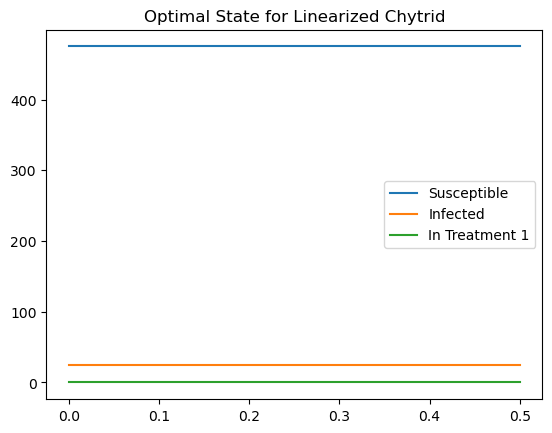

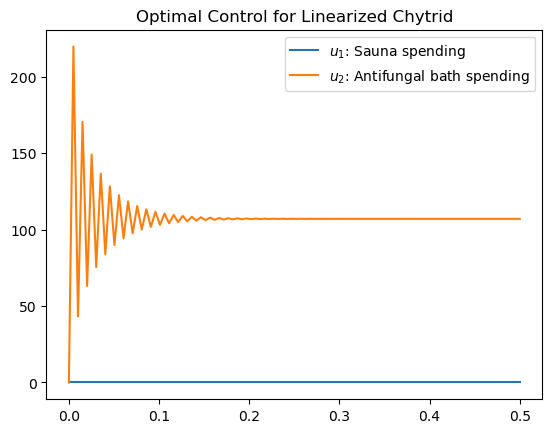

In [4]:
def iterated_lqr(Df_x, Df_u, t_space, x0, u0):
    '''
    Solve for control and state solutions at discrete steps using LQR at each step
    Args:
        Df_x: a function to linearize with respect to x, returns matrix A for LQR
        Df_u: a function to linearize with respect to x, returns matrix B for LQR
        t_space: time steps on which to evaluate our solution
        x0: initial state
        u0: initial control

    Returns:
        state_solutions: array of optimal state over time
        control_solutions: array of optimal control over time

    '''
    # store initial states in our solution
    state_solutions = [x0]
    control_solutions = [u0]
    tf = t_space[-1]

    for i in range(len(t_space) - 1):   # iterate through each time step
        A = Df_x(0, state_solutions[i], control_solutions[i])    # TODO write these functions
        B = Df_u(0, state_solutions[i], control_solutions[i])

        # # test
        # A[-1] = 1e-5
        # A[:,-1] = 1e-5
        # B[-1] = 1e-5

        # print(A)
        # print(type(A))

        x_new, u_new = solve_linearized(A, B, state_solutions[i], tf)   # get next state using LQR
        state_solutions.append(x_new)
        control_solutions.append(u_new)

    return np.array(state_solutions), np.array(control_solutions)

# sample test case
x, u = iterated_lqr(lambda t, x, u: model.f_x(t, x, u), lambda t, x, u: model.f_u(t, x, u), t_space, y0, np.array([0, 0]))
print(x.shape, u.shape)

S, I, T1 = x.T
plt.title("Optimal State for Linearized Chytrid")
plt.plot(t_space, S, label="Susceptible")
plt.plot(t_space, I, label="Infected")
plt.plot(t_space, T1, label="In Treatment 1")
# plt.plot(t_space, D, label="Death")
plt.legend()
plt.show()

plt.title("Optimal Control for Linearized Chytrid")
u1, u2 = u.T
plt.plot(t_space, u1, label=rf'$u_{1}$: Sauna spending')
plt.plot(t_space, u2, label=rf'$u_{2}$: Antifungal bath spending')
plt.legend()

In [5]:
type(model.f_x(0, np.ones(3), np.ones(2)))

numpy.ndarray